In [1]:
GROUP_NAME = "IowaGPT"
NAME = "Amit Boodhoo, Diego Liogon, Eva Singh, Kate Meyer"
PROJECT_NAME = "Project S"
USAGE_OF_CHATGPT = " We used ChatGPT to help us come up with a skeleton or outline for our code. We knew from the last project that random forest was a good model to use, so we asked ChatGPT to help us with the code for that. We also used it to help us with the code for evaluating our model and plotting the results."

## Introduction

**Task:** This is a **Classification** task where we are predicting a categorical label.  

**Dataset Source:** Kaggle Dataset: [Wildfire Risk Dataset 2024-2025 (7 Regions)](https://www.kaggle.com/datasets/alitaqishah/wildfire-risk-dataset-2024-2025-7-regions/data)

**Goal:** We are trying to predict the intensity of a wildfire (`fire_intensity`) based on satellite brightness measurements, confidence scores, and local environmental factors such as temperature, humidity, wind, season, and region.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'  # avoid OpenMP conflicts

from sklearn import model_selection as skms
from sklearn import metrics
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay

print("All libraries imported successfully.")

All libraries imported successfully.


## Methods – Data

**Data Source:** The data is the [Wildfire Risk Dataset 2024–2025 (7 Regions)](https://www.kaggle.com/datasets/alitaqishah/wildfire-risk-dataset-2024-2025-7-regions/data), downloaded directly from Kaggle using the `kagglehub` library. It contains 15,500 satellite fire-detection records.

**Target Variable:**
- `fire_intensity` – Categorical label indicating fire severity (Low, Moderate, High, Extreme). We encoded this to numeric values (0, 1, 2, 3) for modeling.

**Features (Real dataset columns):**
- **Satellite Data:** `brightness_k` (Kelvin), `confidence`, `satellite`, `instrument`.
- **Weather Data:** `temp_max_c` (Maximum temperature °C), `humidity_pct` (Relative humidity %), `wind_max_kmh` (Wind speed), `precip_mm` (Precipitation).
- **Geography/Timing:** `region`, `country`, `season`, `daynight`.
- **Derived Weather Features:** `dryness_index`, `temp_humidity_product`, `wind_dryness`.

**Data Cleaning & Preprocessing Steps:**
1. **Feature Pruning:** Dropped exact location/time identifiers (`latitude`, `longitude`, `acq_date`, `acq_time`, `year`, `month`) to prevent the model from memorizing specific past fires (overfitting).
2. **Leakage Prevention:** Dropped `frp_mw` because `fire_intensity` in this dataset is strongly tied to FRP ranges, which made the original near-perfect results misleading.
3. **Splitting First:** Built the raw feature table and target, then split into an **80% Training Set** and a **20% Held-out Test Set** using `stratify=tgt` to maintain class balance.
4. **Train-Only Preprocessing:** Applied feature engineering, train-mean imputation, and one-hot encoding after the split so the test set was never used to fit preprocessing steps.
5. **Encoding:** Encoded the target variable with `LabelEncoder()` and converted categorical predictors (including `region`, `country`, `season`, and `daynight`) into dummy variables using `pd.get_dummies()` fit from the training data structure.

In [3]:
# 1. Install the library (Run this once, or put an exclamation mark in front if running in Jupyter)
#!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# 2. The exact name of the CSV file inside the Kaggle dataset
file_path = "wildfire_multi_region_dataset.csv"

# 3. Download and load directly into a Pandas DataFrame
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "alitaqishah/wildfire-risk-dataset-2024-2025-7-regions",
  file_path,
)

# 4. Prove it worked!
print("Dataset Shape:", df.shape)
display(df.head())

/var/folders/fj/8q45w7k551n01jgtvgcrt6nm0000gn/T/ipykernel_33496/2770920870.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Dataset Shape: (15500, 21)


,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


In [4]:
# Check for any missing values in the dataset
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Check the balance of our target variable
print("\n--- Fire Intensity Classes ---")
print(df['fire_intensity'].value_counts())

# 3. Drop columns that are just identifiers or won't help predict intensity
# (We drop things like latitude, longitude, and exact dates so the model doesn't overfit to a specific location/time)
columns_to_drop = ['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month']
df_clean = df.drop(columns=columns_to_drop)

# 4. Display the clean dataset info
print("\n--- Cleaned Dataset Info ---")
df_clean.info()

# Data cleaning and raw feature preparation

print("\n--- Preparing Raw Features ---")

# 1. Drop identifier/date columns (risk of location/time overfitting)
columns_to_drop = ['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month']
df_model = df.drop(columns=[c for c in columns_to_drop if c in df.columns]).copy()

# 2. Remove effective target leakage from FRP-derived information
if 'frp_mw' in df_model.columns:
    df_model = df_model.drop(columns=['frp_mw'])
    print("Dropped frp_mw to avoid target-derived leakage.")

# 3. Separate target
tgt_le = LabelEncoder()
tgt = tgt_le.fit_transform(df_model['fire_intensity'])
print("Target classes:", tgt_le.classes_)

X_raw = df_model.drop(columns=['fire_intensity']).copy()


--- Missing Values ---
latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month             0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
frp_mw            0
fire_intensity    0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
dtype: int64

--- Fire Intensity Classes ---
fire_intensity
Moderate    6861
High        4785
Low         2493
Extreme     1361
Name: count, dtype: int64

--- Cleaned Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          15500 non-null  object 
 1   daynight        15500 non-null  object 
 2   region          15500 non-null  object 
 3   country         15500 non-null  ob

## Methods – Training/Validation

**Model Variations Tested:** To find the best-performing configuration, we tested 5 different model variations across 3 different algorithm families:
1. **Baseline Model:** `DummyClassifier` (predicts the most frequent class)
2. **Probabilistic Model:** `GaussianNB` (Naive Bayes)
3. **Ensemble Model 1:** `RandomForestClassifier` (100 trees, depth=10)
4. **Ensemble Model 2:** `RandomForestClassifier` (200 trees, depth=10)
5. **Ensemble Model 3:** `RandomForestClassifier` (300 trees, depth=10)

**Hyperparameters Tuned:** For our ensemble models, we tuned the `n_estimators` hyperparameter, testing forests with 100, 200, and 300 decision trees while holding `max_depth` constant at 10 to prevent severe overfitting. 

**Validation Approach:** We performed an initial 80/20 train/test split. To strictly prevent data leakage, we did not use the 20% test set during the model selection phase. Instead, we evaluated our 5 model variations exclusively on the training data using **5-fold Cross-Validation** (`cv=5`). The model that achieved the highest mean cross-validation accuracy was selected as our final, "best" model.

In [5]:
# Train / Test Split (before preprocessing)
# We split the raw features into 80% for training and 20% for testing
# 'stratify=tgt' ensures the balance of fire intensity classes is maintained in both sets
ftrs_train_raw, ftrs_test_raw, tgt_train, tgt_test = skms.train_test_split(
    X_raw, 
    tgt, 
    test_size=0.20, 
    stratify=tgt, 
    random_state=42
)

print(f"Training set size: {len(ftrs_train_raw)} ({len(ftrs_train_raw)/len(X_raw)*100:.1f}%)")
print(f"Testing set size:  {len(ftrs_test_raw)} ({len(ftrs_test_raw)/len(X_raw)*100:.1f}%)")

# Feature engineering after the split
def add_features(frame):
    frame = frame.copy()
    if 'temp_max_c' in frame.columns and 'humidity_pct' in frame.columns:
        frame['dryness_index'] = frame['temp_max_c'] / (frame['humidity_pct'] + 1e-6)
        frame['temp_humidity_product'] = frame['temp_max_c'] * (100 - frame['humidity_pct'])
    if 'wind_max_kmh' in frame.columns and 'dryness_index' in frame.columns:
        frame['wind_dryness'] = frame['wind_max_kmh'] * frame['dryness_index']
    return frame.replace([np.inf, -np.inf], np.nan)

ftrs_train_raw = add_features(ftrs_train_raw)
ftrs_test_raw = add_features(ftrs_test_raw)

# Impute numeric columns using training-data means only
numeric_cols = ftrs_train_raw.select_dtypes(exclude='object').columns
train_means = ftrs_train_raw[numeric_cols].mean()
ftrs_train_raw[numeric_cols] = ftrs_train_raw[numeric_cols].fillna(train_means)
ftrs_test_raw[numeric_cols] = ftrs_test_raw[numeric_cols].fillna(train_means)

# Convert remaining categorical columns to dummy variables using the training-data structure
cat_cols = ftrs_train_raw.select_dtypes(include='object').columns
print("Encoding categorical columns:", list(cat_cols))
ftrs_train = pd.get_dummies(ftrs_train_raw, columns=cat_cols, drop_first=True)
ftrs_test = pd.get_dummies(ftrs_test_raw, columns=cat_cols, drop_first=True)
ftrs_train, ftrs_test = ftrs_train.align(ftrs_test, join='left', axis=1, fill_value=0)

print(f"\nTraining feature shape: {ftrs_train.shape}")
print(f"Testing feature shape:  {ftrs_test.shape}")
print(f"Total train NaNs remaining: {ftrs_train.isnull().sum().sum()}")
print(f"Total test NaNs remaining:  {ftrs_test.isnull().sum().sum()}")
display(ftrs_train.head())

Training set size: 12400 (80.0%)
Testing set size:  3100 (20.0%)
Encoding categorical columns: ['season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'confidence']

Training feature shape: (12400, 67)
Testing feature shape:  (3100, 67)
Total train NaNs remaining: 0
Total test NaNs remaining:  0


,brightness_k,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,dryness_index,temp_humidity_product,wind_dryness,season_Spring,season_Summer,...,fire_type_Prescribed,fire_type_Savanna,fire_type_Shrubland,fire_type_Wildfire,satellite_NOAA-20,satellite_Suomi-NPP,satellite_TERRA,instrument_VIIRS,confidence_low,confidence_nominal
14965,320.81,30.1,5.0,2.30,29.2,1.030822,2131.08,5.154109,False,False,...,False,False,False,False,False,True,False,True,False,False
5293,342.67,41.9,33.2,2.77,57.3,0.731239,1789.13,24.277137,False,False,...,False,False,False,False,False,False,True,False,False,False
7749,340.26,31.1,3.7,0.45,49.6,0.627016,1567.44,2.319960,True,False,...,False,False,False,False,True,False,False,True,False,True
8512,344.25,46.7,19.6,1.70,27.2,1.716912,3399.76,33.651469,False,False,...,False,False,False,False,False,False,False,False,False,True
6991,311.23,39.6,0.4,1.15,24.9,1.590361,2973.96,0.636145,True,False,...,False,False,False,False,False,False,False,False,False,False


Model Name                          | Train Acc  | CV Acc (5-fold)
----------------------------------------------------------------------
Baseline (Most Frequent)            | 0.4427     | 0.4427
Gaussian Naive Bayes                | 0.2286     | 0.2289
Random Forest (100, depth=10)       | 0.6053     | 0.4785
Random Forest (200, depth=10)       | 0.6081     | 0.4808
Random Forest (300, depth=10)       | 0.6038     | 0.4798

--- Best Model Selection ---
Winner:              Random Forest (200, depth=10)
CV Accuracy:         0.4808


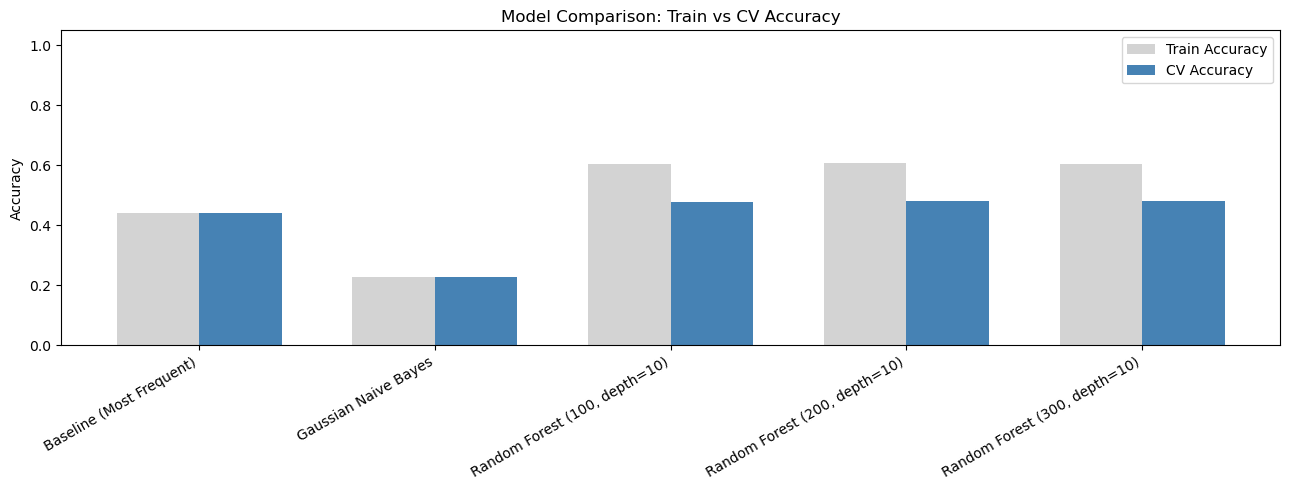

In [6]:
# Model training and validation

models_to_try = {
    "Baseline (Most Frequent)":         DummyClassifier(strategy='most_frequent'),
    "Gaussian Naive Bayes":             GaussianNB(),
    "Random Forest (100, depth=10)":    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Random Forest (200, depth=10)":    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Random Forest (300, depth=10)":    RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
}

print(f"{'Model Name':<35} | {'Train Acc':<10} | {'CV Acc (5-fold)':<15}")
print("-" * 70)

results = {}
for name, model in models_to_try.items():
    model.fit(ftrs_train, tgt_train)
    # 1. Training Accuracy
    train_acc = metrics.accuracy_score(tgt_train, model.predict(ftrs_train))
    
    # 2. Cross-Validation Accuracy (Handles Validation rubric requirement)
    cv_scores = skms.cross_val_score(model, ftrs_train, tgt_train, cv=5, scoring='accuracy')
    cv_acc    = cv_scores.mean()

    results[name] = {"train_acc": train_acc, "cv_acc": cv_acc, "model_obj": model}
    print(f"{name:<35} | {train_acc:.4f}     | {cv_acc:.4f}")

# --- Select best model by CV accuracy ---
best_model_name = max(results, key=lambda x: results[x]["cv_acc"])
best_model = results[best_model_name]["model_obj"]

print(f"\n--- Best Model Selection ---")
print(f"Winner:              {best_model_name}")
print(f"CV Accuracy:         {results[best_model_name]['cv_acc']:.4f}")

# --- Bar chart of CV accuracy across all models ---
model_names = list(results.keys())
cv_accs     = [results[m]["cv_acc"] for m in model_names]
train_accs  = [results[m]["train_acc"] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, train_accs, width, label="Train Accuracy", color="lightgray")
bars2 = ax.bar(x + width/2, cv_accs,    width, label="CV Accuracy",    color="steelblue")
ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison: Train vs CV Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Results on Test Set

**Selected Model:**  
After removing the FRP-based leakage and re-running the workflow, the best model based on 5-fold cross-validation was the **Random Forest (200 trees, depth=10)**. Its accuracy was only modestly better than the baseline, which makes the corrected evaluation much more realistic.

**Evaluation on Test Set:**  
We evaluate the final model on the 20% held-out test set that was **never seen during training or model selection**. We report:
- Overall accuracy
- Full classification report (precision, recall, F1 per class)
- Confusion Matrix
- Feature importance bar chart (what the model relied on most)


Best Model: Random Forest (200, depth=10)
Test Set Accuracy: 0.4848

--- Classification Report ---
              precision    recall  f1-score   support

     Extreme       0.77      0.38      0.51       272
        High       0.43      0.16      0.24       957
         Low       0.00      0.00      0.00       499
    Moderate       0.48      0.91      0.63      1372

    accuracy                           0.48      3100
   macro avg       0.42      0.36      0.34      3100
weighted avg       0.41      0.48      0.39      3100



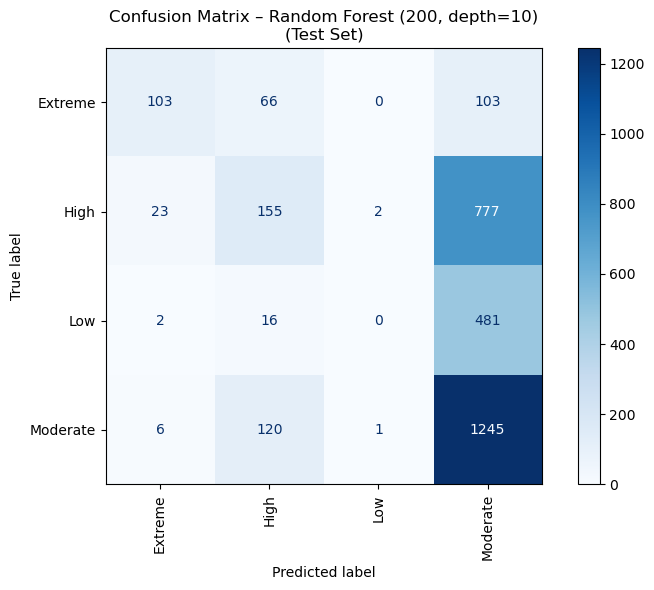

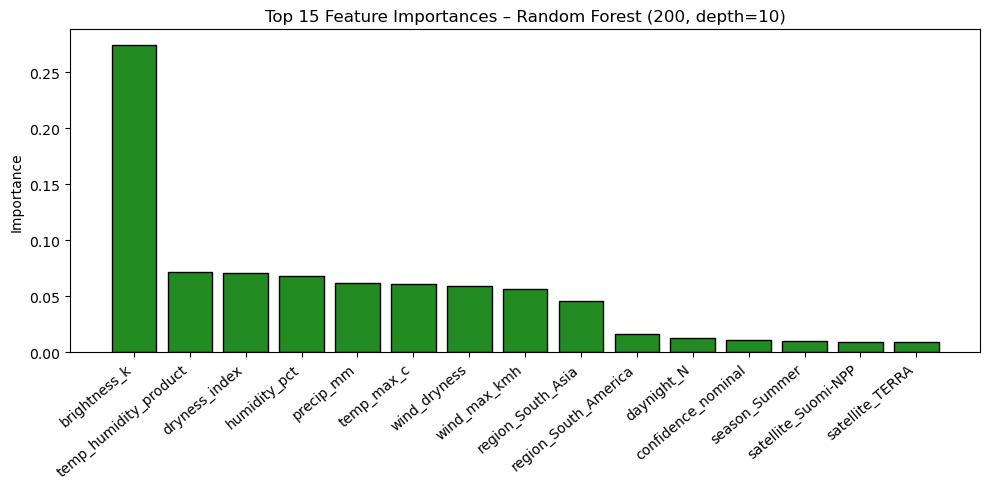

In [7]:
# Results on test set

# Evaluate the best model on the untouched test set
tgt_pred_test = best_model.predict(ftrs_test)

test_acc = metrics.accuracy_score(tgt_test, tgt_pred_test)
print(f"Best Model: {best_model_name}")
print(f"Test Set Accuracy: {test_acc:.4f}\n")

print("--- Classification Report ---")
print(metrics.classification_report(tgt_test, tgt_pred_test,
                                    target_names=tgt_le.classes_))

# --- Confusion Matrix ---
cm = metrics.confusion_matrix(tgt_test, tgt_pred_test)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tgt_le.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation="vertical")
ax.set_title(f"Confusion Matrix – {best_model_name}\n(Test Set)")
plt.tight_layout()
plt.show()

# --- Feature Importances (Random Forest only) ---
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feat_names  = ftrs_train.columns.tolist()
    sorted_idx  = np.argsort(importances)[::-1]

    top_n = min(15, len(feat_names))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(top_n), importances[sorted_idx[:top_n]], color="forestgreen", edgecolor="black")
    ax.set_xticks(range(top_n))
    ax.set_xticklabels([feat_names[i] for i in sorted_idx[:top_n]], rotation=40, ha="right")
    ax.set_ylabel("Importance")
    ax.set_title(f"Top {top_n} Feature Importances – {best_model_name}")
    plt.tight_layout()
    plt.show()


## Discussion & Conclusion

**Best Model:**  
The **Random Forest with 200 trees and max depth 10** performed best in cross-validation, but its advantage over the baseline was modest once the FRP leakage was removed.

**Key Findings:**  
- The corrected feature set produced much lower accuracy than the original near-perfect result, which showed that the earlier notebook was benefiting from target-derived leakage through `frp_mw`.
- The Random Forest models still performed slightly better than the baseline and Naive Bayes, suggesting there is some usable signal in brightness, weather, season, and regional context.
- Gaussian Naive Bayes performed poorly, which is consistent with the lecture discussion that correlated features can violate the model's independence assumptions.

**Limitations:**  
- Some classes may be imbalanced, which could inflate accuracy on majority classes.
- We dropped spatial (lat/lon) and temporal (date) features to avoid overfitting, but spatial patterns in fire risk are real — future work could encode region more richly.
- Random Forest is a "black-box" model; interpretability is limited compared to a single decision tree.

**Impressions / Takeaways:**  
- The most important fix was not adding a more complex model; it was cleaning up the workflow so the test set stayed fully held out and the target-derived FRP feature was removed.
- Stratified splitting and 5-fold cross-validation were important because the classes were imbalanced.
- If we were to redo this project, we would stay within course scope but try a broader lecture-supported comparison such as KNN or decision trees alongside the current models.

## Disclosures

**Use of AI / Claude (Anthropic):**  
- Claude was used to help structure code cells, suggest feature engineering ideas (e.g., `frp_brightness_ratio`, `dryness_index`), and assist with Markdown formatting and documentation.
- All decisions regarding which models to try, how to interpret results, what features matter, and the final conclusions were made by the team.

**Academic Integrity Note:**  
- AI assistance was limited to coding scaffolding and does not replace our understanding of the methods.
- All analysis, hyperparameter choices, and narrative explanations reflect our own reasoning and learning.
